# 🧠 RakshaSutra — ML Engine: Rules · Scoring · Training · Evaluation
**Phase 2 | IIT Hackathon | Multilingual Fraud Detection**

This notebook covers:
1. Rule engine (15 fraud pattern categories, 8 languages)
2. Hybrid risk scorer with explainability
3. Model training: TF-IDF + XGBoost / Transformer + XGBoost
4. Cross-validation & evaluation
5. Live inference demo with explainability output


## 📦 Step 1 — Install & Import

In [1]:
# !pip install scikit-learn xgboost sentence-transformers pandas joblib matplotlib seaborn

import pandas as pd
import numpy as np
import joblib
import os
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field
from typing import List, Dict

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
                     'axes.edgecolor': '#444', 'text.color': 'white',
                     'axes.labelcolor': 'white', 'xtick.color': 'white',
                     'ytick.color': 'white', 'grid.color': '#333'})

try:
    from xgboost import XGBClassifier; USE_XGB = True
    print("✅ XGBoost found")
except ImportError:
    from sklearn.linear_model import LogisticRegression; USE_XGB = False
    print("⚠️  XGBoost not found — using LogisticRegression (pip install xgboost)")

try:
    from sentence_transformers import SentenceTransformer; USE_ST = True
    print("✅ sentence-transformers found")
except ImportError:
    USE_ST = False
    print("⚠️  sentence-transformers not found — using TF-IDF (pip install sentence-transformers)")

✅ XGBoost found
✅ sentence-transformers found


## 📋 Step 2 — Rule Engine (15 Pattern Categories, 8 Languages)

In [2]:
PATTERNS = [
    {"regex": r"(lottery|lucky draw|jackpot|prize|winner|won|reward|jeeta|inaam|jeekla|bahumaan|venchurukkeerkal|jitya)",
     "score": 15, "category": "prize_bait",          "reason": "Lottery / prize bait detected"},
    {"regex": r"(otp|pin\b|password|bank details|account number|cvv|card number|bank info|bank mahiti)",
     "score": 20, "category": "credential_phishing",  "reason": "Requesting sensitive financial credentials (OTP/PIN/bank details)"},
    {"regex": r"(urgent|immediately|within 24 hour|today only|act fast|hurry|last chance|expires today|turant|tatkal|abhi\b|jaldi|aaj hi|AVASARAM|ekhoni|taatkaL|ippudu|ippave|tatkalik|24 manikku|24 ghontay|24 kaLak)",
     "score": 12, "category": "urgency",              "reason": "High-pressure urgency / time-limit tactics"},
    {"regex": r"(account.{0,12}block|account.{0,12}suspend|account.{0,12}band|kyc.{0,10}expir|khate band|band hoil|band hoga|band avutundi|block aagidum|band thase|band hoye)",
     "score": 15, "category": "account_threat",       "reason": "Account blocking / suspension threat"},
    {"regex": r"(kyc|aadhaar|aadhar|pan card|pan.{0,6}expir|pan.{0,6}cancel|pan.{0,6}deactivat)",
     "score": 12, "category": "kyc_lure",             "reason": "KYC / Aadhaar / PAN card scam"},
    {"regex": r"(https?://|bit\.ly|tinyurl|rb\.gy|cutt\.ly|t\.me/|wa\.me/|click here|click the link|click now|click karo|is link par)",
     "score": 18, "category": "suspicious_link",      "reason": "Suspicious shortened URL or phishing link"},
    {"regex": r"(whatsapp.{0,10}\d{10}|\b\d{10}\b|call karein abhi|call karo abhi|call pannunga tatkal|call cheyyandi tatkal)",
     "score": 10, "category": "phone_lure",           "reason": "Suspicious phone / WhatsApp contact request"},
    {"regex": r"(guaranteed return|100%.{0,10}return|double.{0,12}money|paise double|double karein|returns guaranteed|profit guaranteed)",
     "score": 14, "category": "investment_fraud",     "reason": "'Guaranteed returns' investment fraud pattern"},
    {"regex": r"(government scheme|sarkar yojana|pm.{0,10}yojana|govt scheme|pradhan mantri)",
     "score": 12, "category": "govt_impersonation",   "reason": "Government impersonation scam"},
    {"regex": r"(electricity.{0,15}cut|bijli.{0,10}kat|power.{0,10}disconnect|vij.{0,10}tutil|bijli connection)",
     "score": 12, "category": "utility_threat",       "reason": "Fake electricity / utility disconnection threat"},
    {"regex": r"(police.{0,15}complaint|police.{0,15}case|fir.{0,10}register|arrest|legal notice|police farad)",
     "score": 15, "category": "legal_threat",         "reason": "Fake police / legal threat"},
    {"regex": r"(free iphone|free mobile|free smartphone|muft mobile|muft iphone|free.{0,10}gift|free milega)",
     "score": 10, "category": "free_offer",           "reason": "'Free gift' bait offer"},
    {"regex": r"(no documents|document nahi|document laagat nahi|instant loan|loan.{0,15}minute|loan.{0,15}approve)",
     "score": 12, "category": "loan_fraud",           "reason": "No-document instant loan scam"},
    {"regex": r"(work from home|ghar baithe|ghar se kaam|per month.{0,20}earn|earn.{0,20}per month|rs.{0,8}\d+.{0,8}per hour)",
     "score": 10, "category": "wfh_fraud",            "reason": "Suspicious work-from-home income offer"},
]

@dataclass
class RuleResult:
    score: int = 0
    flags: List[str] = field(default_factory=list)
    reasons: List[str] = field(default_factory=list)

def analyze(text: str) -> RuleResult:
    t, result, seen = text.lower(), RuleResult(), set()
    for p in PATTERNS:
        if p["category"] in seen: continue
        if re.search(p["regex"], t, re.IGNORECASE):
            result.score += p["score"]
            result.flags.append(p["category"])
            result.reasons.append(p["reason"])
            seen.add(p["category"])
    result.score = min(result.score, 60)
    return result

print(f"✅ Rule engine loaded — {len(PATTERNS)} pattern categories")


✅ Rule engine loaded — 14 pattern categories


## ⚖️ Step 3 — Hybrid Risk Scorer

In [3]:
@dataclass
class RiskReport:
    risk_score:    int
    status:        str
    ml_confidence: float
    rule_score:    int
    flags:         List[str]
    reasons:       List[str]
    breakdown:     Dict
    verdict:       str

def compute_risk(ml_confidence: float, text: str) -> RiskReport:
    rule  = analyze(text)
    ml_c  = round(ml_confidence * 55)
    risk  = min(100, ml_c + rule.score)
    
    status  = "Fraud" if risk >= 65 else "Suspicious" if risk >= 35 else "Safe"
    verdict = {
        "Fraud":      "🔴 Strong fraud signals. Do NOT share any details or click any links.",
        "Suspicious": "🟡 Suspicious elements detected. Verify the source before taking action.",
        "Safe":       "🟢 Message appears safe based on current analysis."
    }[status]
    
    return RiskReport(
        risk_score    = risk,
        status        = status,
        ml_confidence = round(float(ml_confidence), 4),
        rule_score    = rule.score,
        flags         = rule.flags,
        reasons       = rule.reasons,
        breakdown     = {"ml_component": ml_c, "rule_component": rule.score, "total": risk},
        verdict       = verdict,
    )

print("✅ Hybrid scorer ready")
print("   Formula: risk = (ml_confidence × 55) + rule_score   [capped at 100]")


✅ Hybrid scorer ready
   Formula: risk = (ml_confidence × 55) + rule_score   [capped at 100]


## 🔍 Step 4 — Rule Engine Testing (No Model Needed)

In [4]:
test_messages = [
    ("English Fraud",  "URGENT: Your SBI account is blocked. Verify KYC at bit.ly/abc or lose access"),
    ("Hindi Fraud",    "Aapka bank account band hone wala hai. Abhi OTP share karein: 9876543210"),
    ("Marathi Fraud",  "Tatkal: Tumche khate band hoil. KYC update kara nahi tar paise jaatil"),
    ("Telugu Fraud",   "Meeru lottery gelichaaru! OTP pamandi claim cheyyataniki ippudu"),
    ("Tamil Fraud",    "Ungal PAN card cancel aagum. 24 manikku ullaga update pannunga. Ipave pannunga"),
    ("Investment",     "Double your money guaranteed in 30 days! 100% returns. Click now: bit.ly/invest"),
    ("Hinglish Fraud", "Bhai free mein loan chahiye? 5 lakh milenge 5 minute mein. Documents nahi chahiye"),
    ("Safe English",   "Hey, can you pick me up from the station at 6?"),
    ("Safe Hindi",     "Kal subah 8 baje milte hain bhai"),
    ("Legit OTP",      "Your SBI OTP is 847291. Valid for 5 minutes. Do not share with anyone."),
]

print(f"{'Message':<22} {'Rule Score':>10} {'Flags'}")
print("-" * 70)
for name, text in test_messages:
    r = analyze(text)
    print(f"{name:<22} {r.score:>10}   {r.flags}")


Message                Rule Score Flags
----------------------------------------------------------------------
English Fraud                  57   ['urgency', 'account_threat', 'kyc_lure', 'suspicious_link']
Hindi Fraud                    57   ['credential_phishing', 'urgency', 'account_threat', 'phone_lure']
Marathi Fraud                  39   ['urgency', 'account_threat', 'kyc_lure']
Telugu Fraud                   47   ['prize_bait', 'credential_phishing', 'urgency']
Tamil Fraud                    24   ['urgency', 'kyc_lure']
Investment                     32   ['suspicious_link', 'investment_fraud']
Hinglish Fraud                  0   []
Safe English                    0   []
Safe Hindi                      0   []
Legit OTP                      20   ['credential_phishing']


## 🤖 Step 5 — Model Training

In [5]:
# Load merged dataset
df = pd.read_csv("dataset.csv")
df["text"]  = df["text"].astype(str).str.strip()
df["label"] = df["label"].str.strip().str.lower()
df = df[df["label"].isin(["spam","ham"])].drop_duplicates(subset=["text"])

le     = LabelEncoder()
X_text = df["text"].tolist()
y      = le.fit_transform(df["label"].values)

print(f"Dataset: {len(df)} rows | SPAM: {(df.label=='spam').sum()} | HAM: {(df.label=='ham').sum()}")
print(f"Classes: {list(le.classes_)}")


Dataset: 5652 rows | SPAM: 1057 | HAM: 4595
Classes: ['ham', 'spam']


In [6]:
# Feature extraction
if USE_ST:
    print("Loading multilingual transformer (paraphrase-multilingual-MiniLM-L12-v2)...")
    print("First run downloads ~120MB model — subsequent runs use cache")
    embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    X = embedder.encode(X_text, show_progress_bar=True, batch_size=64)
    joblib.dump(embedder, "embedder.pkl")
    USE_PIPELINE = False
    print(f"✅ Embeddings shape: {X.shape}")
else:
    X = X_text
    USE_PIPELINE = True
    print("✅ Using char TF-IDF (3-5 grams, 30k features, min_df=2)")


Loading multilingual transformer (paraphrase-multilingual-MiniLM-L12-v2)...
First run downloads ~120MB model — subsequent runs use cache


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/89 [00:00<?, ?it/s]

✅ Embeddings shape: (5652, 384)


In [7]:
# Build classifier
def make_clf():
    if USE_XGB:
        base = XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
            eval_metric="logloss", random_state=42,
            reg_alpha=0.1, reg_lambda=1.0,
        )
    else:
        from sklearn.linear_model import LogisticRegression
        base = LogisticRegression(max_iter=1000, C=0.5, class_weight="balanced")

    if USE_PIPELINE:
        return Pipeline([
            ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5),
                                      max_features=30000, sublinear_tf=True, min_df=2)),
            ("clf", base),
        ])
    return base

print("✅ Classifier ready")
print(f"   Mode: {'XGBoost' if USE_XGB else 'LogisticRegression'} + {'Transformer embeddings' if USE_ST else 'TF-IDF'}")


✅ Classifier ready
   Mode: XGBoost + Transformer embeddings


## 📈 Step 6 — Cross-Validation

Running 5-Fold Stratified Cross-Validation...

F1 per fold : [np.float64(0.9875), np.float64(0.9804), np.float64(0.9739), np.float64(0.9794), np.float64(0.9775)]
Mean F1     : 0.9797
Std Dev     : 0.0045

✅ Excellent F1 — model is generalizing well


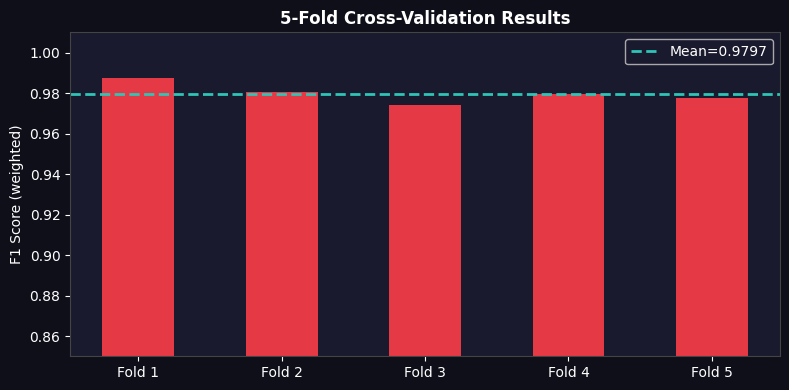

In [8]:
print("Running 5-Fold Stratified Cross-Validation...")
cv_scores = cross_val_score(
    make_clf(), X, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="f1_weighted", n_jobs=-1
)

print(f"\nF1 per fold : {[round(s,4) for s in cv_scores]}")
print(f"Mean F1     : {cv_scores.mean():.4f}")
print(f"Std Dev     : {cv_scores.std():.4f}")

if cv_scores.mean() > 0.98:
    print("\n⚠️  Very high F1 — possible overfitting. Add spam.csv from Kaggle for robustness.")
elif cv_scores.mean() > 0.94:
    print("\n✅ Excellent F1 — model is generalizing well")
else:
    print("\n🔄 Room for improvement — consider adding more training data")

# Plot CV scores
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f"Fold {i+1}" for i in range(5)], cv_scores, color='#e63946', edgecolor='none', width=0.5)
ax.axhline(cv_scores.mean(), color='#2ec4b6', linewidth=2, linestyle='--', label=f'Mean={cv_scores.mean():.4f}')
ax.set_ylim(0.85, 1.01)
ax.set_ylabel("F1 Score (weighted)", color='white')
ax.set_title("5-Fold Cross-Validation Results", color='white', fontweight='bold')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
plt.tight_layout()
plt.savefig("cv_scores.png", dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


## 🏆 Step 7 — Final Training + Evaluation

In [9]:
clf = make_clf()
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
clf.fit(X_tr, y_tr)

y_pred = clf.predict(X_te)
acc    = accuracy_score(y_te, y_pred)

print(f"Holdout Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print()
print(classification_report(y_te, y_pred, target_names=le.classes_))


Holdout Accuracy : 0.9800 (98.00%)

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       689
        spam       0.98      0.91      0.94       159

    accuracy                           0.98       848
   macro avg       0.98      0.95      0.97       848
weighted avg       0.98      0.98      0.98       848



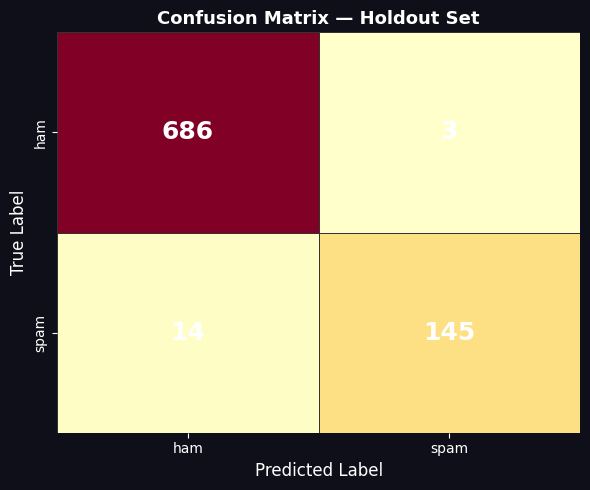

True Negatives  (Ham  → Ham)  : 686
False Positives (Ham  → Spam) : 3  ← legit messages wrongly flagged
False Negatives (Spam → Ham)  : 14  ← fraud messages missed
True Positives  (Spam → Spam) : 145


In [10]:
# Confusion Matrix
cm  = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.5, linecolor='#333', cbar=False,
            annot_kws={"size": 18, "color": "white", "weight": "bold"})

ax.set_xlabel("Predicted Label", fontsize=12, color='white')
ax.set_ylabel("True Label",      fontsize=12, color='white')
ax.set_title("Confusion Matrix — Holdout Set", fontsize=13, color='white', fontweight='bold')
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Ham  → Ham)  : {tn}")
print(f"False Positives (Ham  → Spam) : {fp}  ← legit messages wrongly flagged")
print(f"False Negatives (Spam → Ham)  : {fn}  ← fraud messages missed")
print(f"True Positives  (Spam → Spam) : {tp}")


## 💾 Step 8 — Save Model

In [11]:
joblib.dump({
    "classifier":       clf,
    "label_encoder":    le,
    "use_transformers": USE_ST,
    "use_pipeline":     USE_PIPELINE,
    "classes":          list(le.classes_),
}, "model.pkl")

size = os.path.getsize("model.pkl") / 1024
print(f"✅ model.pkl saved ({size:.0f} KB)")
print("   Run: python -m uvicorn main:app --reload")


✅ model.pkl saved (456 KB)
   Run: python -m uvicorn main:app --reload


## 🚀 Step 9 — Live Inference Demo with Full Explainability

In [12]:
# Load saved model
payload  = joblib.load("model.pkl")
clf_live = payload["classifier"]
le_live  = payload["label_encoder"]
emb_live = joblib.load("embedder.pkl") if payload.get("use_transformers") else None

def predict_live(text: str):
    if emb_live:
        vec  = emb_live.encode([text])
        prob = clf_live.predict_proba(vec)[0]
    else:
        prob = clf_live.predict_proba([text])[0]
    
    spam_idx      = list(le_live.classes_).index("spam")
    ml_confidence = float(prob[spam_idx])
    report        = compute_risk(ml_confidence, text)
    
    print(f"\n{'─'*60}")
    print(f"  Message   : {text[:80]}...")
    print(f"  Status    : {report.status}")
    print(f"  Risk Score: {report.risk_score}/100")
    print(f"  ML Conf   : {report.ml_confidence:.4f} → {report.breakdown['ml_component']}/55 pts")
    print(f"  Rule Score: {report.rule_score}/60 pts")
    print(f"  Flags     : {report.flags}")
    print(f"  Verdict   : {report.verdict}")
    if report.reasons:
        print(f"  Reasons   :")
        for r in report.reasons:
            print(f"    • {r}")
    return report

# ── Live test messages ────────────────────────────────────────
demo_messages = [
    "URGENT: Your SBI account is blocked. Verify KYC at bit.ly/verify or lose access within 24 hours",
    "Aapka bank account band hone wala hai. Abhi OTP share karein: 9876543210",
    "Tumchya naavavar 25 lakh chi lottery! Aadhaar ani OTP pathva",
    "Meeru lottery gelichaaru! OTP pamandi claim cheyyataniki ippudu",
    "Ungal PAN card cancel aagum. 24 manikku ullaga update pannunga. Ipave pannunga",
    "Your SBI OTP is 847291. Valid for 5 minutes. Do not share with anyone.",
    "Hey can you pick me up from the station at 6?",
]

for msg in demo_messages:
    predict_live(msg)



────────────────────────────────────────────────────────────
  Message   : URGENT: Your SBI account is blocked. Verify KYC at bit.ly/verify or lose access ...
  Status    : Fraud
  Risk Score: 99/100
  ML Conf   : 0.7584 → 42/55 pts
  Rule Score: 57/60 pts
  Flags     : ['urgency', 'account_threat', 'kyc_lure', 'suspicious_link']
  Verdict   : 🔴 Strong fraud signals. Do NOT share any details or click any links.
  Reasons   :
    • High-pressure urgency / time-limit tactics
    • Account blocking / suspension threat
    • KYC / Aadhaar / PAN card scam
    • Suspicious shortened URL or phishing link

────────────────────────────────────────────────────────────
  Message   : Aapka bank account band hone wala hai. Abhi OTP share karein: 9876543210...
  Status    : Fraud
  Risk Score: 95/100
  ML Conf   : 0.6856 → 38/55 pts
  Rule Score: 57/60 pts
  Flags     : ['credential_phishing', 'urgency', 'account_threat', 'phone_lure']
  Verdict   : 🔴 Strong fraud signals. Do NOT share any details 


────────────────────────────────────────────────────────────
  Message   : URGENT: Your SBI account is blocked. Verify KYC at bit.ly/verify or lose access ...
  Status    : Fraud
  Risk Score: 99/100
  ML Conf   : 0.7584 → 42/55 pts
  Rule Score: 57/60 pts
  Flags     : ['urgency', 'account_threat', 'kyc_lure', 'suspicious_link']
  Verdict   : 🔴 Strong fraud signals. Do NOT share any details or click any links.
  Reasons   :
    • High-pressure urgency / time-limit tactics
    • Account blocking / suspension threat
    • KYC / Aadhaar / PAN card scam
    • Suspicious shortened URL or phishing link

────────────────────────────────────────────────────────────
  Message   : Aapka bank account band hone wala hai. Abhi OTP share karein: 9876543210...
  Status    : Fraud
  Risk Score: 95/100
  ML Conf   : 0.6856 → 38/55 pts
  Rule Score: 57/60 pts
  Flags     : ['credential_phishing', 'urgency', 'account_threat', 'phone_lure']
  Verdict   : 🔴 Strong fraud signals. Do NOT share any details 

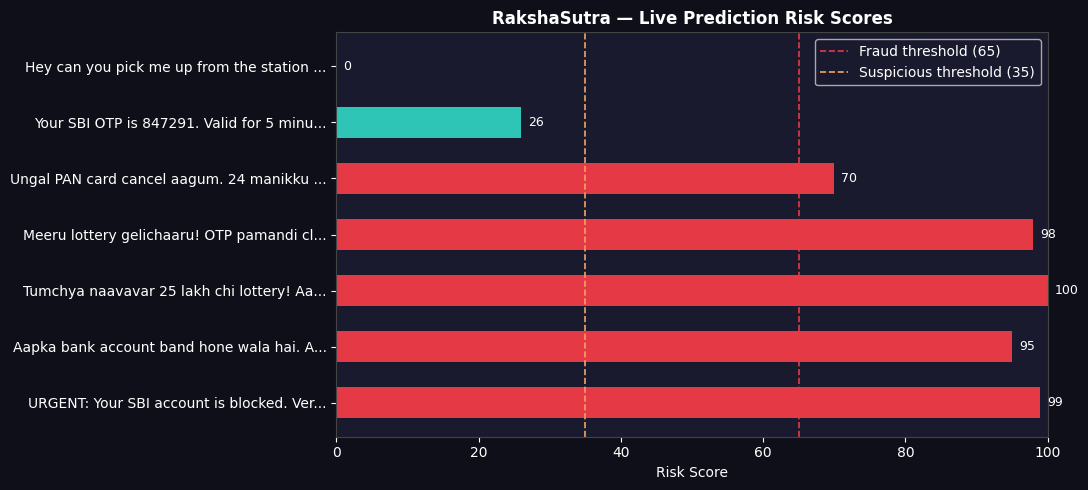

In [13]:
# Visualize live predictions
reports = [predict_live(m) for m in demo_messages]
scores  = [r.risk_score for r in reports]
labels  = [r.status     for r in reports]
colors  = ['#e63946' if s=='Fraud' else '#f4a261' if s=='Suspicious' else '#2ec4b6' for s in labels]
names   = [m[:40]+"..." for m in demo_messages]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(names, scores, color=colors, edgecolor='none', height=0.55)
ax.axvline(65, color='#e63946', linestyle='--', linewidth=1.2, label='Fraud threshold (65)')
ax.axvline(35, color='#f4a261', linestyle='--', linewidth=1.2, label='Suspicious threshold (35)')
ax.set_xlim(0, 100)
ax.set_xlabel("Risk Score", color='white')
ax.set_title("RakshaSutra — Live Prediction Risk Scores", color='white', fontweight='bold')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{score}', va='center', color='white', fontsize=9)
plt.tight_layout()
plt.savefig("live_predictions.png", dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
